In [4]:
from functions import *
import pandas as pd

In [4]:
def plot_keypoints_from_csv(data, frame, File_name, Frame_num):
    data = data.reset_index(drop=True)
    num_boxes = len(data)
    rows = cols = int(np.ceil(np.sqrt(num_boxes)))  # n*n の正方形に配置
    fig, axs = plt.subplots(rows, cols, figsize=(15, 15), constrained_layout=True)
    axs = axs.flatten()  # 配列をフラット化
    plt.suptitle(f"Coordinates based on CSV :{File_name}.mov \n Frame:{Frame_num}", fontsize = 20)

    for idx, row in data.iterrows():
        if idx >= len(axs):
            break

        ax = axs[idx]
        x1, y1 = row['Head_X'], row['Head_Y']
        x2, y2 = row['Tail_X'], row['Tail_Y']

        # 少し大きめにクロップ
        pad = 10  # パディングサイズ
        x_min = max(0, min(x1, x2) - pad)
        y_min = max(0, min(y1, y2) - pad)
        x_max = min(frame.shape[1], max(x1, x2) + pad)
        y_max = min(frame.shape[0], max(y1, y2) + pad)

        cropped_frame = frame[int(y_min):int(y_max), int(x_min):int(x_max)]
        ax.imshow(cropped_frame, extent=(x_min, x_max, y_max, y_min))
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)
        ax.set_title(f"CSV ID {int(row['ID'])}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        # キーポイントを描画
        colors = ['red', 'green', 'blue']  # Head, Middle, Tail の色
        keypoints = [
            (row['Head_X'], row['Head_Y']),
            (row['Middle_X'], row['Middle_Y']),
            (row['Tail_X'], row['Tail_Y'])
        ]
        keypoint_names = ['Head', 'Middle', 'Tail']

        # for j, (x, y) in enumerate(keypoints):
        #     cropped_x, cropped_y = x - x_min, y - y_min
        #     ax.plot(cropped_x, cropped_y, 'o', color=colors[j], markersize=12)  # キーポイントを指定色でプロット
        #     ax.text(cropped_x + 5, cropped_y, f"{keypoint_names[j]} ({x:.1f}, {y:.1f})", color=colors[j], fontsize=15)
        for j, (x, y) in enumerate(keypoints):
            ax.plot(x, y, 'o', color=colors[j], markersize=12)  # キーポイントを指定色でプロット
            ax.text(x, y, f"{keypoint_names[j]} ({x:.1f}, {y:.1f})", color=colors[j], fontsize=15)
    # 空のサブプロットを非表示にする
    for ax in axs[num_boxes:]:
        ax.axis('off')

In [3]:
def plot_keypoints_with_metadata(xyxy, keypoints_data, frame, File_name, Frame_num):
    num_boxes = len(xyxy)
    rows = cols = int(np.ceil(np.sqrt(num_boxes)))  # n*n の正方形に配置
    fig, axs = plt.subplots(rows, cols, figsize=(23, 15), constrained_layout=True)
    plt.suptitle(f"Model Predictions Movie:{File_name}.mov \n Frame:{Frame_num}", fontsize=20)
    axs = axs.flatten()  # 配列をフラット化

    for idx, (ax, box, keypoints) in enumerate(zip(axs, xyxy, keypoints_data)):
        x1, y1, x2, y2 = map(int, box)

        # 少し大きめにクロップ
        pad = 10  # パディングサイズ
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(frame.shape[1], x2 + pad)
        y2 = min(frame.shape[0], y2 + pad)

        cropped_frame = frame[y1:y2, x1:x2]
        ax.imshow(cropped_frame, extent=(x1, x2, y2, y1))
        ax.set_xlim(x1, x2)
        ax.set_ylim(y2, y1)
        ax.set_title(f"Model Predictions Box {idx}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        # キーポイントを描画
        colors = ['red', 'green', 'blue']  # Head, Middle, Tail の色
        keypoint_names = ['Head', 'Middle', 'Tail']
        for j, (x, y) in enumerate(keypoints):
            ax.plot(x, y, 'o', color=colors[j], markersize=12)  # キーポイントを指定色でプロット
            ax.text(x + 5, y, f"{keypoint_names[j]} ({x:.1f}, {y:.1f})", color=colors[j], fontsize=15)

    # 空のサブプロットを非表示にする
    for ax in axs[num_boxes:]:
        ax.axis('off')

In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
# YOLOv8(torch)モデルロード
#model = YOLO("./runs/pose/train20241204//weights/last.pt")
model = YOLO("./runs/pose/train/weights/best.pt")
File_name = 'D5-1_L5_ori'
Frame_num = 1861
cap = cv2.VideoCapture('../video/241227_original/{}.mov'.format(File_name))
cap.set(cv2.CAP_PROP_POS_FRAMES, Frame_num)
ret, frame = cap.read()
results = model(frame, conf = 4e-6)
xyxy = results[0].boxes.xyxy.cpu().numpy()
keypoints_data = results[0].keypoints.xy.cpu().numpy()
conf = results[0].boxes.conf
keypoint_names = ["Head", "Middle", "Tail"]
plot_keypoints_with_metadata(xyxy, keypoints_data, frame, File_name, Frame_num)


0: 480x640 16 poses, 12.8ms
Speed: 2.1ms preprocess, 12.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


###### results[0].keypoints.

#### traj_csv = pd.read_csv(f'./csvs/trajectory/{File_name}.csv')
traj_csv = pd.read_csv(f'./manual_correction/{File_name}.csv')
traj_csv_ext = traj_csv[traj_csv.Frame == Frame_num]

plot_keypoints_from_csv(traj_csv_ext, frame, File_name, Frame_num)

In [204]:
cap

< cv2.VideoCapture 0x7e86be67cd90>

In [1263]:
results.keypoints

AttributeError: 'list' object has no attribute 'keypoints'

# 過学習用のデータ整形

Enter the frame number to analyze (or -1 to quit):  80



0: 480x640 18 poses, 12.8ms
Speed: 1.6ms preprocess, 12.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


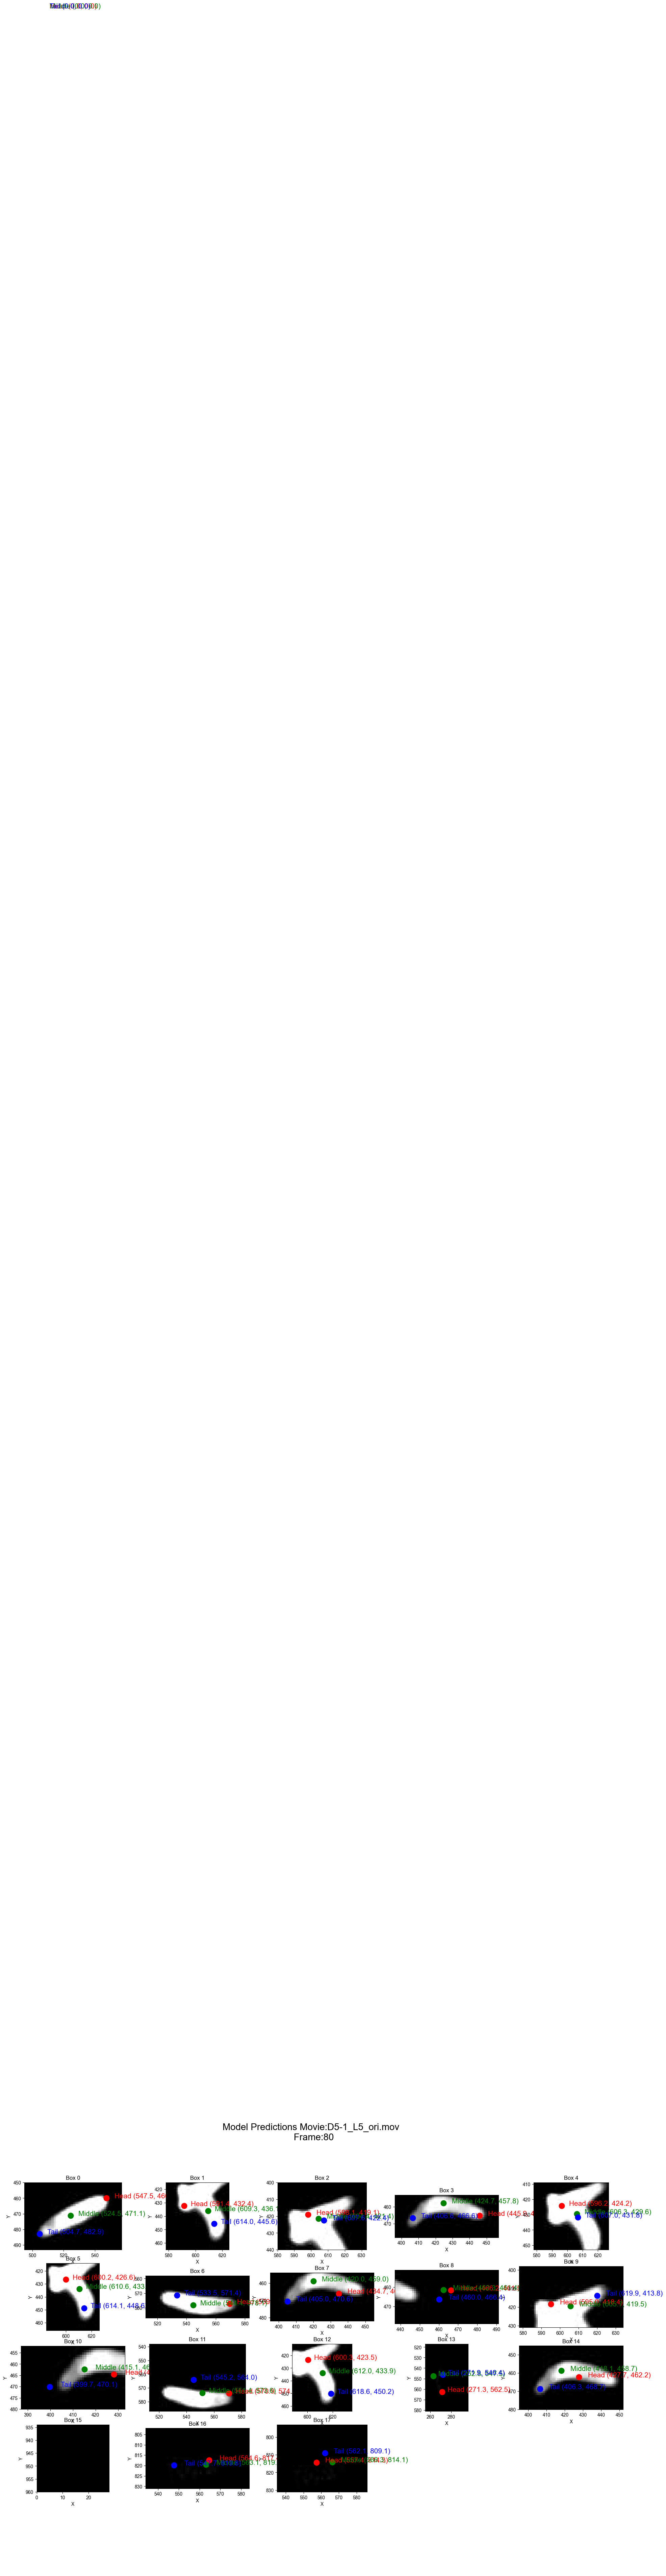

Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  1


Available boxes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


Select a box index for ID 1 (or 'flip <box_index>' to flip Head and Tail):  flip 0


Assigned Box 0 to ID 1 with Head and Tail flipped.


Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  2


Available boxes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


Select a box index for ID 2 (or 'flip <box_index>' to flip Head and Tail):  flip 3


Assigned Box 3 to ID 2 with Head and Tail flipped.


Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  3


Available boxes: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


Select a box index for ID 3 (or 'flip <box_index>' to flip Head and Tail):  flip 9


Assigned Box 9 to ID 3 with Head and Tail flipped.


Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  4


Available boxes: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17]


Select a box index for ID 4 (or 'flip <box_index>' to flip Head and Tail):  12


Assigned Box 12 to ID 4.


Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  5


Available boxes: [1, 2, 4, 5, 6, 7, 8, 10, 11, 13, 14, 15, 16, 17]


Select a box index for ID 5 (or 'flip <box_index>' to flip Head and Tail):  6


Assigned Box 6 to ID 5.


Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame):  done


Finished assigning IDs for this frame.
Results appended to ../annotations/overfittings/csvs/D5-1_L5_ori_manual_keypoints.csv.


Enter the frame number to analyze (or -1 to quit):  -1


Exiting.


In [6]:
import cv2
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def plot_keypoints_with_metadata(xyxy, keypoints_data, frame, File_name, Frame_num):
    num_boxes = len(xyxy)
    rows = cols = int(np.ceil(np.sqrt(num_boxes)))  # n*n の正方形に配置
    fig, axs = plt.subplots(rows, cols, figsize=(23, 15), constrained_layout=True)
    plt.suptitle(f"Model Predictions Movie:{File_name}.mov \n Frame:{Frame_num}", fontsize=20)
    axs = axs.flatten()  # 配列をフラット化

    for idx, (ax, box, keypoints) in enumerate(zip(axs, xyxy, keypoints_data)):
        x1, y1, x2, y2 = map(int, box)

        # 少し大きめにクロップ
        pad = 10  # パディングサイズ
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(frame.shape[1], x2 + pad)
        y2 = min(frame.shape[0], y2 + pad)

        cropped_frame = frame[y1:y2, x1:x2]
        ax.imshow(cropped_frame, extent=(x1, x2, y2, y1))
        ax.set_xlim(x1, x2)
        ax.set_ylim(y2, y1)
        ax.set_title(f"Box {idx}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        # キーポイントを描画
        colors = ['red', 'green', 'blue']  # Head, Middle, Tail の色
        keypoint_names = ['Head', 'Middle', 'Tail']
        for j, (x, y) in enumerate(keypoints):
            ax.plot(x, y, 'o', color=colors[j], markersize=12)  # キーポイントを指定色でプロット
            ax.text(x + 5, y, f"{keypoint_names[j]} ({x:.1f}, {y:.1f})", color=colors[j], fontsize=15)

    # 空のサブプロットを非表示にする
    for ax in axs[num_boxes:]:
        ax.axis('off')

    plt.show()

def main():
    model = YOLO("./runs/pose/train/weights/best.pt")
    File_name = 'D5-1_L5_ori'
    #output_csv = f"../annotations/overfittings/csvs/annotation_{File_name}_manual.csv"
    output_csv = f"../annotations/overfittings/csvs/{File_name}_manual_keypoints.csv"

    # Check if the CSV file exists; if not, create it with a header
    if not os.path.exists(output_csv):
        with open(output_csv, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Frame', 'ID', 'Box', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y', 'Tail_X', 'Tail_Y'])

    while True:
        try:
            Frame_num = int(input("Enter the frame number to analyze (or -1 to quit): "))
            if Frame_num == -1:
                print("Exiting.")
                break

            # Load the specified frame
            cap = cv2.VideoCapture(f'../video/241227_original/{File_name}.mov')
            cap.set(cv2.CAP_PROP_POS_FRAMES, Frame_num)
            ret, frame = cap.read()
            if not ret:
                print(f"Frame {Frame_num} could not be read. Please try another frame.")
                continue

            # Run YOLO model on the frame
            results = model(frame, conf=1e-5)
            xyxy = results[0].boxes.xyxy.cpu().numpy()
            keypoints_data = results[0].keypoints.xy.cpu().numpy()

            # Plot the keypoints with metadata
            plot_keypoints_with_metadata(xyxy, keypoints_data, frame, File_name, Frame_num)

            # User input for assigning IDs
            assigned_ids = {}
            available_boxes = list(range(len(xyxy)))
            while available_boxes:
                try:
                    user_input = input(f"Assign an ID (or 'done' to finish assigning, 'skip' to skip this frame): ").strip()
                    if user_input.lower() == 'done':
                        print("Finished assigning IDs for this frame.")
                        break
                    if user_input.lower() == 'skip':
                        print("Skipped this frame.")
                        assigned_ids = {}
                        break

                    assigned_id = int(user_input)

                    print(f"Available boxes: {available_boxes}")
                    box_input = input(f"Select a box index for ID {assigned_id} (or 'flip <box_index>' to flip Head and Tail): ").strip()

                    if box_input.startswith('flip'):
                        _, box_idx = box_input.split()
                        box_idx = int(box_idx)
                        if box_idx in available_boxes:
                            flipped_keypoints = keypoints_data[box_idx].copy()
                            flipped_keypoints[[0, 2]] = flipped_keypoints[[2, 0]]  # Flip Head and Tail
                            assigned_ids[assigned_id] = (box_idx, flipped_keypoints)
                            available_boxes.remove(box_idx)
                            print(f"Assigned Box {box_idx} to ID {assigned_id} with Head and Tail flipped.")
                        else:
                            print(f"Box {box_idx} is not available. Try again.")
                    else:
                        box_idx = int(box_input)
                        if box_idx in available_boxes:
                            assigned_ids[assigned_id] = (box_idx, keypoints_data[box_idx])
                            available_boxes.remove(box_idx)
                            print(f"Assigned Box {box_idx} to ID {assigned_id}.")
                        else:
                            print(f"Box {box_idx} is not available. Try again.")

                except ValueError:
                    print("Invalid input. Please enter a valid integer for ID and box index.")

            # Append results to the CSV file
            with open(output_csv, mode='a', newline='') as file:
                writer = csv.writer(file)
                for assigned_id, (box_idx, keypoints) in assigned_ids.items():
                    writer.writerow([Frame_num, assigned_id, box_idx, *keypoints.flatten()])

            print(f"Results appended to {output_csv}.")

        except ValueError:
            print("Please enter a valid frame number.")

if __name__ == "__main__":
    main()


In [1646]:
cap = cv2.VideoCapture(f'../video/241227_original/{File_name}.mov')
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
if not ret:
    print(f"Frame {Frame_num} could not be read. Please try another frame.")

# Run YOLO model on the frame
results = model(frame, conf=1e-4)
xyxy = results[0].boxes.xyxy.cpu().numpy()
keypoints_data = results[0].keypoints.xy.cpu().numpy()


0: 480x640 6 poses, 296.7ms
Speed: 1.3ms preprocess, 296.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


In [1652]:
keypoints_data[3].shape

(3, 2)

In [56]:
frame.shape

(960, 1280, 3)